In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

In [3]:
df.shape

(1470, 35)

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa

In [8]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [9]:
# Missing values
df.isnull().sum()

# Duplicates
df.duplicated().sum()

# Constant columns (zero variance — useless features)
df.nunique().sort_values()

# Class balance of your target
df['Attrition'].value_counts(normalize=True)

Attrition
No     0.838776
Yes    0.161224
Name: proportion, dtype: float64

In [10]:
df.nunique().sort_values()

EmployeeCount                  1
Over18                         1
StandardHours                  1
Attrition                      2
OverTime                       2
PerformanceRating              2
Gender                         2
BusinessTravel                 3
Department                     3
MaritalStatus                  3
RelationshipSatisfaction       4
StockOptionLevel               4
JobSatisfaction                4
EnvironmentSatisfaction        4
JobInvolvement                 4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

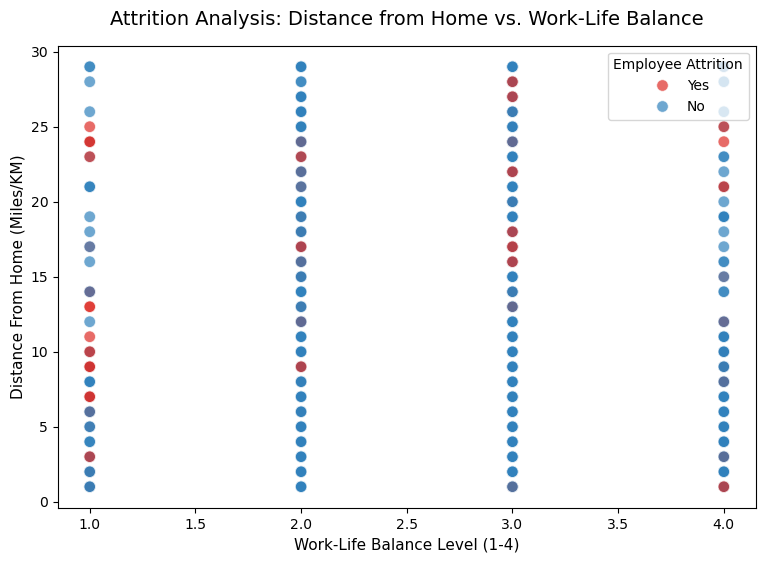

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Reset the figure size so it's easy to read
plt.figure(figsize=(9, 6))

# Seaborn will automatically assign sharp, distinct colors to 'Yes' and 'No'
sns.scatterplot(
    data=df, 
    x='WorkLifeBalance', 
    y='DistanceFromHome', 
    hue='Attrition',       # This tells Seaborn to color by 'Yes' or 'No'
    palette=['#DE2D26', '#3182BD'], # Explicitly forces Solid Red for Yes, Solid Blue for No
    alpha=0.7,
    s=70                   # Makes the dots a bit larger and easier to see
)

plt.title('Attrition Analysis: Distance from Home vs. Work-Life Balance', fontsize=14, pad=15)
plt.xlabel('Work-Life Balance Level (1-4)', fontsize=11)
plt.ylabel('Distance From Home (Miles/KM)', fontsize=11)

# Puts the legend neatly outside or in a clear spot
plt.legend(title='Employee Attrition', loc='upper right')
plt.show()

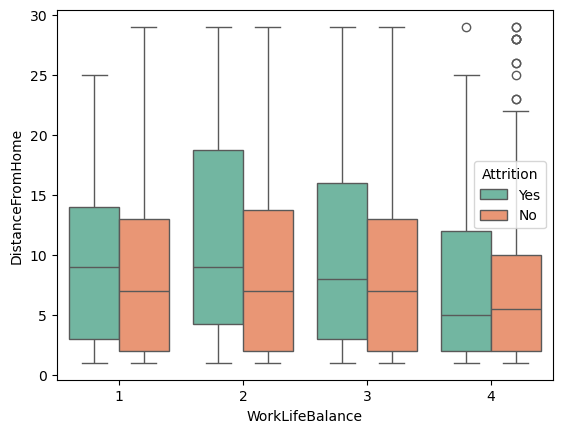

In [14]:
sns.boxplot(
    data=df, 
    x='WorkLifeBalance', 
    y='DistanceFromHome', 
    hue='Attrition', 
    palette= 'Set2'
)
plt.show()

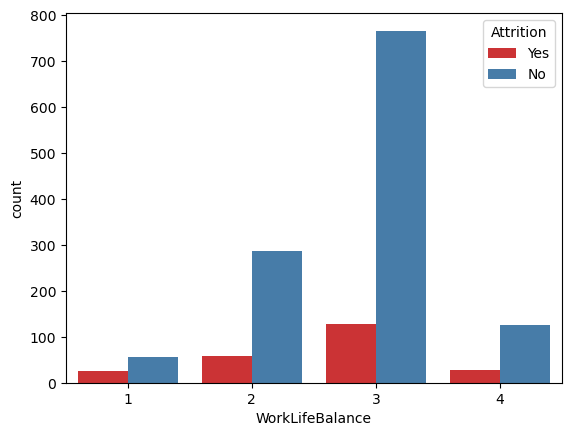

In [15]:
sns.countplot(
    data=df, 
    x='WorkLifeBalance', 
    hue='Attrition', 
    palette='Set1'
)
plt.show()

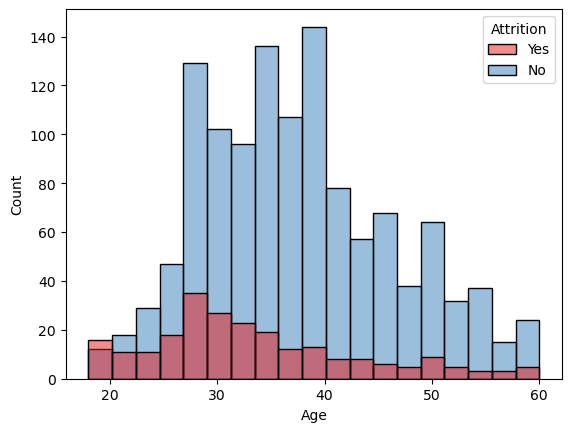

In [16]:
sns.histplot(
    data=df, 
    x='Age', 
    hue='Attrition', 
    palette='Set1'
)
plt.show()

In [17]:
df[df['Age']<20]['Attrition'].value_counts()

Attrition
Yes    10
No      7
Name: count, dtype: int64

In [18]:
below20 = df[df['Age']<=20]

In [19]:
below20['Attrition'].value_counts()

Attrition
Yes    16
No     12
Name: count, dtype: int64

In [20]:
below20

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
102,20,Yes,Travel_Frequently,871,Research & Development,6,3,Life Sciences,1,137,...,2,80,0,1,5,3,1,0,1,0
127,19,Yes,Travel_Rarely,528,Sales,22,1,Marketing,1,167,...,4,80,0,0,2,2,0,0,0,0
149,19,No,Travel_Rarely,1181,Research & Development,3,1,Medical,1,201,...,4,80,0,1,3,3,1,0,0,0
171,19,Yes,Travel_Frequently,602,Sales,1,1,Technical Degree,1,235,...,1,80,0,1,5,4,0,0,0,0
177,19,Yes,Travel_Rarely,303,Research & Development,2,3,Life Sciences,1,243,...,3,80,0,1,3,2,1,0,1,0
296,18,Yes,Travel_Rarely,230,Research & Development,3,3,Life Sciences,1,405,...,3,80,0,0,2,3,0,0,0,0
301,18,No,Travel_Rarely,812,Sales,10,3,Medical,1,411,...,1,80,0,0,2,3,0,0,0,0
422,19,Yes,Travel_Rarely,489,Human Resources,2,2,Technical Degree,1,566,...,3,80,0,1,3,4,1,0,0,0
457,18,Yes,Travel_Frequently,1306,Sales,5,3,Marketing,1,614,...,4,80,0,0,3,3,0,0,0,0
487,20,No,Travel_Rarely,959,Research & Development,1,3,Life Sciences,1,657,...,4,80,0,1,0,4,1,0,0,0


In [21]:
df['Age_Group'] = np.where(df['Age'] <= 20, '20', 'Older')

In [22]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age_Group
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,Older
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,Older
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,Older
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,Older
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,Older


In [23]:
numeric_comparison = df.groupby('Age_Group')[['MonthlyIncome', 'DistanceFromHome', 'EnvironmentSatisfaction', 'HourlyRate']].mean()
print(numeric_comparison)

           MonthlyIncome  DistanceFromHome  EnvironmentSatisfaction  \
Age_Group                                                             
20           2098.392857          7.928571                 2.821429   
Older        6588.456311          9.217060                 2.719834   

           HourlyRate  
Age_Group              
20          64.214286  
Older       65.923717  


In [24]:
df['StandardHours'].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

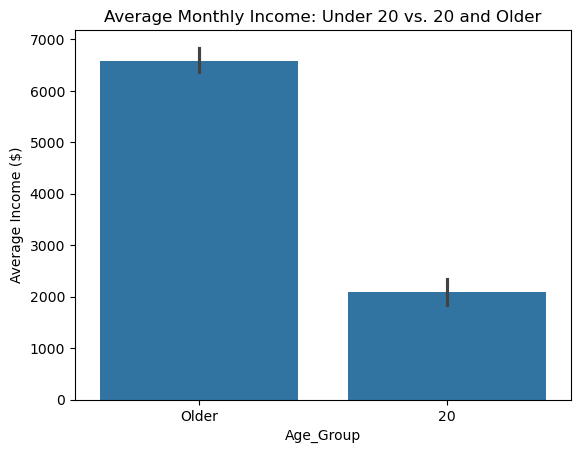

In [25]:
sns.barplot(data=df, x='Age_Group', y='MonthlyIncome')
plt.title('Average Monthly Income: Under 20 vs. 20 and Older')
plt.ylabel('Average Income ($)')
plt.show()

In [26]:
df['EmployeeCount'].nunique

<bound method IndexOpsMixin.nunique of 0       1
1       1
2       1
3       1
4       1
       ..
1465    1
1466    1
1467    1
1468    1
1469    1
Name: EmployeeCount, Length: 1470, dtype: int64>

In [27]:
clean_df = df.drop(columns = ['EmployeeCount','EmployeeNumber','Over18','StandardHours'])

In [28]:
clean_df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Age_Group'],
      dtype='object')

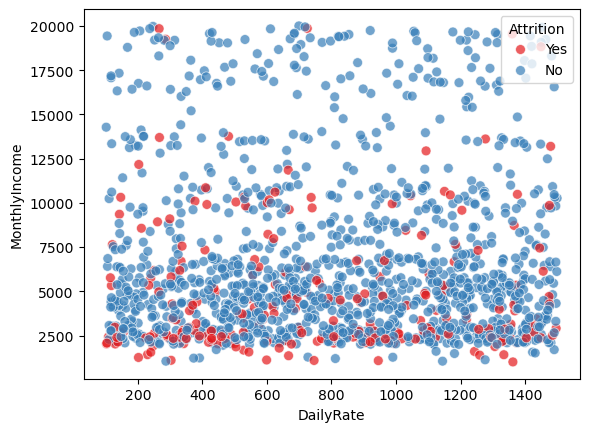

In [29]:
sns.scatterplot(
    data=df, 
    x='DailyRate', 
    y='MonthlyIncome', 
    hue='Attrition', 
    palette='Set1', 
    alpha=0.7,
    s=50  # Size of the dots
) 
plt.show()

In [30]:
clean_df['is_under21'] = np.where(df['Age'] < 21, 1 , 0)

In [31]:
clean_df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Age_Group,is_under21
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,8,0,1,6,4,0,5,Older,0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,1,10,3,3,10,7,1,7,Older,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,0,7,3,3,0,0,0,0,Older,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,0,8,3,3,8,7,3,0,Older,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,1,6,3,3,2,2,2,2,Older,0


In [32]:
clean_df = clean_df.drop(columns = ['Age_Group'])

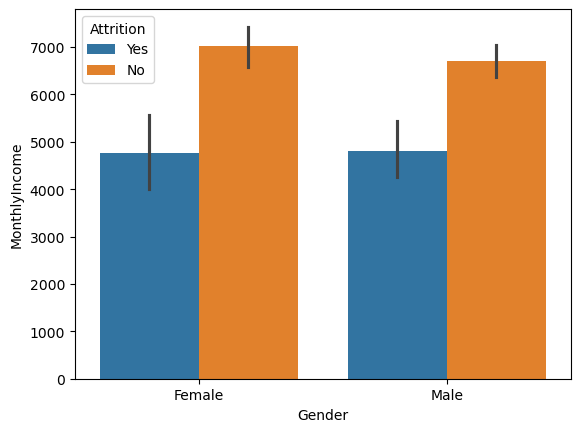

In [33]:
sns.barplot(data=clean_df, x='Gender', y='MonthlyIncome', hue="Attrition")
plt.show()

In [34]:
clean_df['Gender'].value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [35]:
# Check the average Job Level for women by their Attrition status
female_level_check = clean_df[clean_df['Gender'] == 'Female'].groupby('Attrition')['JobLevel'].mean()
print("Average Job Level for Women:\n", female_level_check)

print("\n" + "="*40 + "\n")

# Let's see the exact breakdown of roles for the women who left
female_leavers_roles = clean_df[(clean_df['Gender'] == 'Female') & (clean_df['Attrition'] == 'Yes')]['JobRole'].value_counts()
print("Roles of Women Who Left:\n", female_leavers_roles)

Average Job Level for Women:
 Attrition
No     2.197605
Yes    1.655172
Name: JobLevel, dtype: float64


Roles of Women Who Left:
 JobRole
Sales Executive              20
Research Scientist           17
Laboratory Technician        16
Sales Representative         16
Human Resources               6
Healthcare Representative     5
Manufacturing Director        4
Manager                       2
Research Director             1
Name: count, dtype: int64


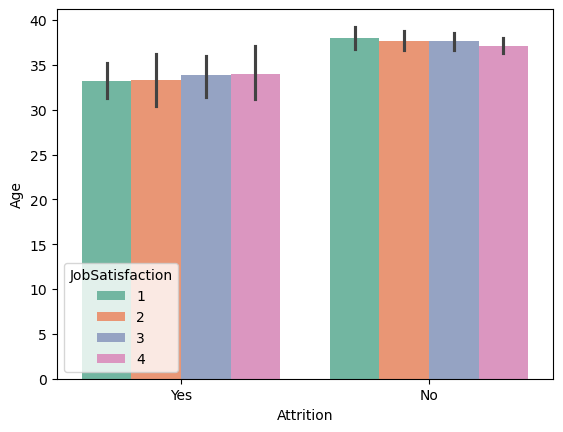

In [36]:
sns.barplot(data=clean_df, y='Age', x='Attrition', hue="JobSatisfaction", palette='Set2')
plt.show()

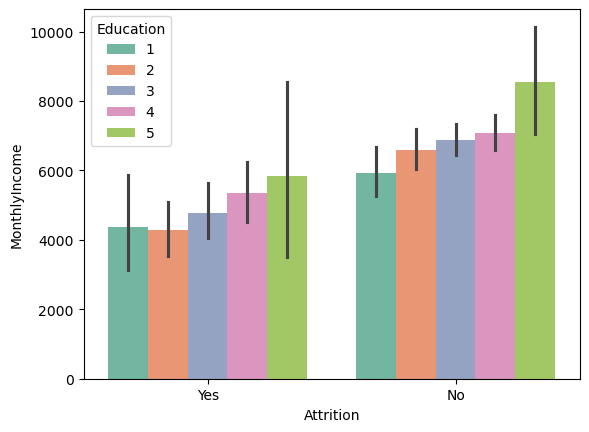

In [37]:
sns.barplot(data=clean_df, y='MonthlyIncome', x='Attrition', hue="Education", palette='Set2')
plt.show()

<Axes: xlabel='Age', ylabel='MonthlyIncome'>

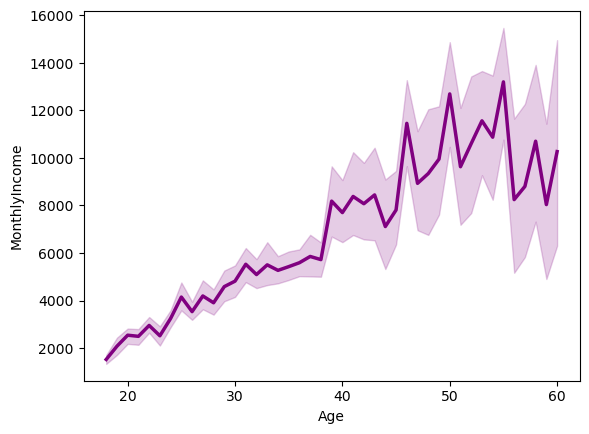

In [38]:
sns.lineplot(
    data=clean_df, 
    x='Age', 
    y='MonthlyIncome',  
    color='purple', 
    linewidth=2.5
)

<Axes: xlabel='Age', ylabel='MonthlyIncome'>

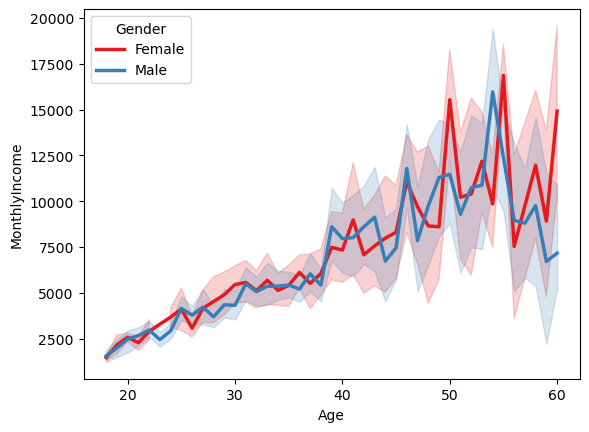

In [39]:
sns.lineplot(
    data=clean_df, 
    x='Age', 
    y='MonthlyIncome', 
    hue='Gender',  
    palette='Set1', 
    linewidth=2.5
)

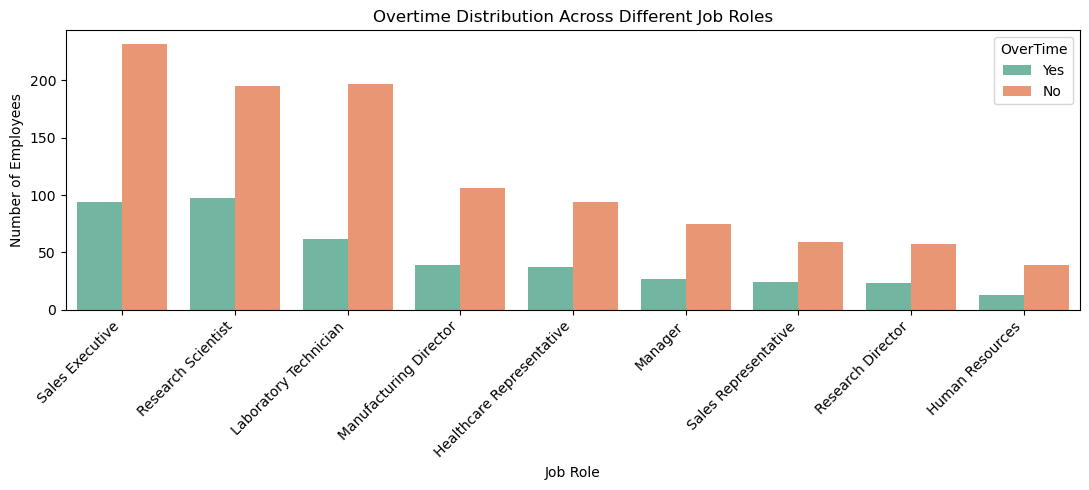

In [40]:
plt.figure(figsize=(11, 5))
# A categorical countplot shows exactly where the overtime culture is concentrated
sns.countplot(data=clean_df, x='JobRole', hue='OverTime', palette='Set2')
plt.xticks(rotation=45, ha='right')
plt.title('Overtime Distribution Across Different Job Roles')
plt.xlabel('Job Role')
plt.ylabel('Number of Employees')
plt.tight_layout()
plt.show()

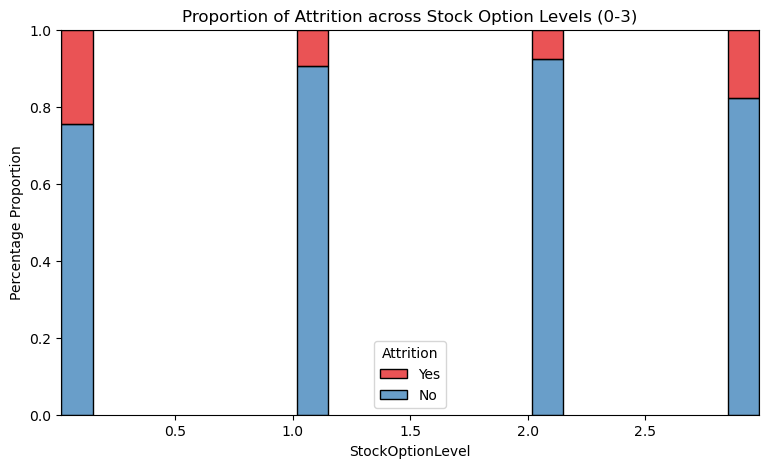

In [41]:
plt.figure(figsize=(9, 5))
# A stacked histogram shows if giving stock options keeps people around
sns.histplot(data=clean_df, x='StockOptionLevel', hue='Attrition', multiple='fill', shrink=0.8, palette='Set1')
plt.title('Proportion of Attrition across Stock Option Levels (0-3)')
plt.ylabel('Percentage Proportion')
plt.show()

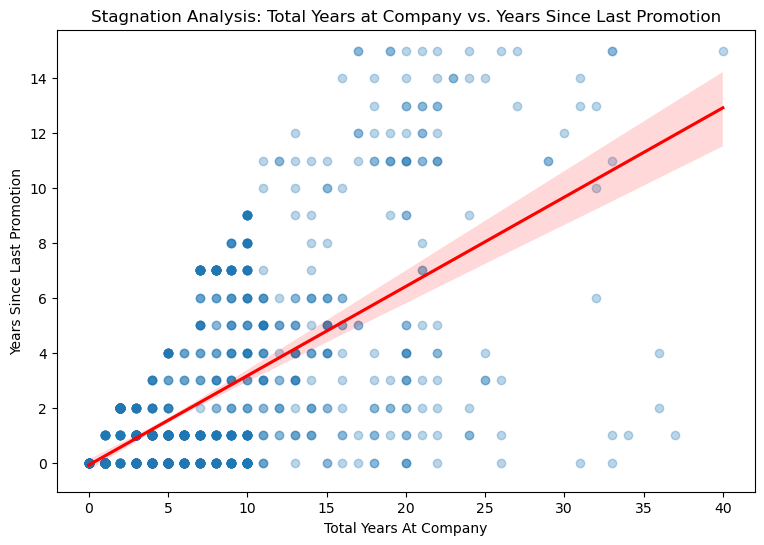

In [42]:
plt.figure(figsize=(9, 6))
# This draws a scatter plot with an automatic statistical line of best fit
sns.regplot(data=clean_df, x='YearsAtCompany', y='YearsSinceLastPromotion', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Stagnation Analysis: Total Years at Company vs. Years Since Last Promotion')
plt.xlabel('Total Years At Company')
plt.ylabel('Years Since Last Promotion')
plt.show()

C:\Users\USER\miniconda3\envs\ml\lib\site-packages\seaborn\axisgrid.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(**kwargs)
C:\Users\USER\miniconda3\envs\ml\lib\site-packages\seaborn\axisgrid.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(**kwargs)
C:\Users\USER\miniconda3\envs\ml\lib\site-packages\seaborn\axisgrid.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(**kwargs)


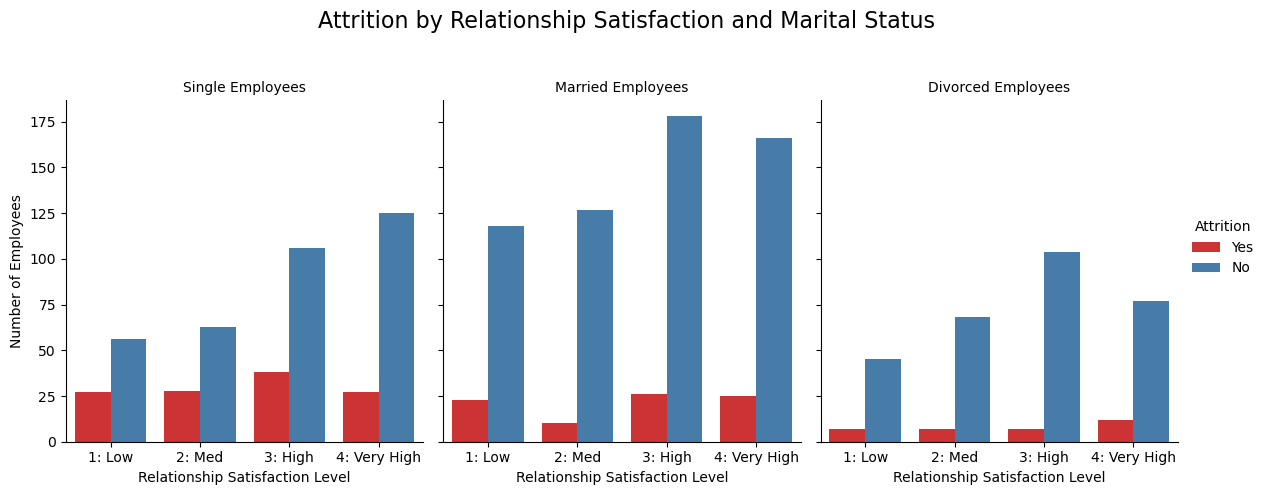

In [43]:
g = sns.catplot(
    data=clean_df, 
    x='RelationshipSatisfaction', 
    hue='Attrition', 
    col='MaritalStatus', 
    kind='count',
    palette='Set1',
    height=5, 
    aspect=0.8
)

# Clean up the styling and labels
g.set_axis_labels("Relationship Satisfaction Level", "Number of Employees")
g.set_titles("{col_name} Employees")
g.set(xticklabels=["1: Low", "2: Med", "3: High", "4: Very High"])

plt.subplots_adjust(top=0.8)
g.fig.suptitle('Attrition by Relationship Satisfaction and Marital Status', fontsize=16)
plt.show()

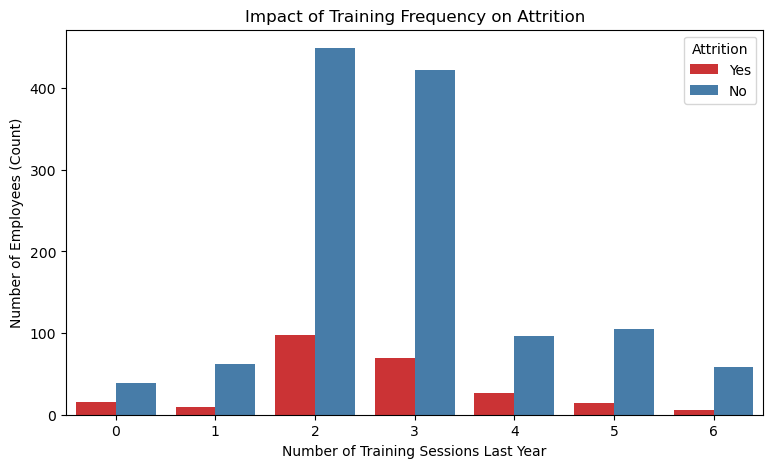

In [45]:
plt.figure(figsize=(9, 5))
# Countplot handles the discrete number of training sessions perfectly
sns.countplot(
    data=clean_df, 
    x='TrainingTimesLastYear', 
    hue='Attrition', 
    palette='Set1'
)

plt.title('Impact of Training Frequency on Attrition')
plt.xlabel('Number of Training Sessions Last Year')
plt.ylabel('Number of Employees (Count)')
plt.show()